# Model Evaluation


## Objective

The objective of this notebook is to evaluate the performance of trained models
using appropriate classification metrics and to interpret the results
from a data science perspective.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
df = pd.read_csv("ads_dataset_processed.csv")

X = df.drop("Purchased", axis=1)
y = df["Purchased"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Confusion Matrix

The confusion matrix provides insight into the types of classification errors.


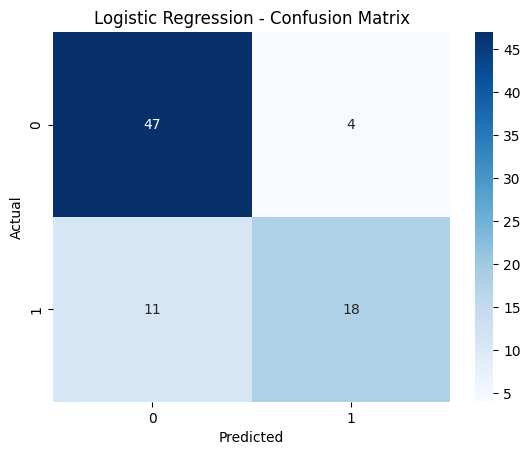

In [ ]:
y_pred_lr = log_reg.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


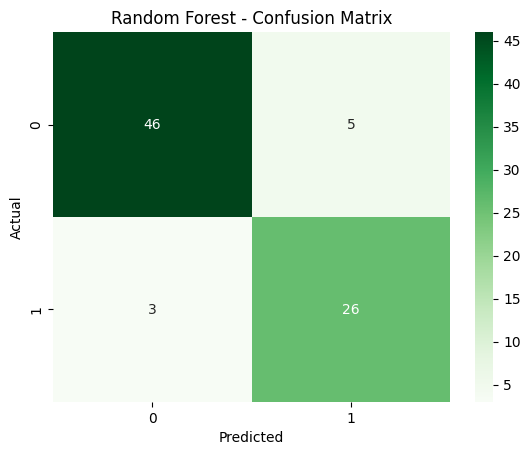

In [ ]:
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Classification Report

Precision, recall, and F1-score provide a more detailed performance evaluation
than accuracy alone.


In [ ]:
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        51
           1       0.82      0.62      0.71        29

    accuracy                           0.81        80
   macro avg       0.81      0.77      0.78        80
weighted avg       0.81      0.81      0.81        80


Random Forest Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



## ROC-AUC Analysis

ROC-AUC measures the model's ability to distinguish between classes
across different threshold values.


In [ ]:
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

roc_auc_lr, roc_auc_rf


(np.float64(0.905341446923597), np.float64(0.920554428668019))

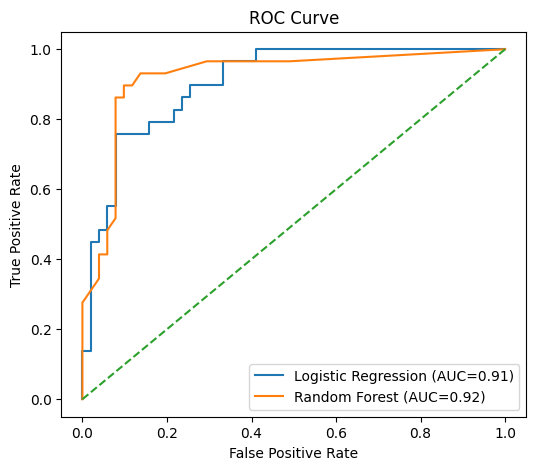

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Model Comparison & Interpretation

- Logistic Regression provides strong interpretability and stable performance.
- Random Forest achieves higher ROC-AUC, indicating better discrimination capability.
- Depending on business requirements, model selection may prioritize either
  interpretability or predictive power.


## Limitations and Future Work

- The dataset contains a limited number of features.
- Additional behavioral or temporal features could improve performance.
- Hyperparameter tuning and cross-validation could further optimize the models.


## Conclusion

The evaluation results demonstrate that machine learning models can effectively
predict advertisement purchase behavior.
This notebook completes the end-to-end modeling workflow.
